# Predicting House Prices with Linear Regression
### OASIS INFOBYTE - Data Analytics Internship | Level 2, Task 1

**Author:** *Minal Sadiq*
**Track:** Data Analytics

---

**Roadmap**
1. Data Loading & Structural Inspection
2. Data Cleaning (documented) & Outlier Handling
3. Exploratory Analysis of the Target Variable (Price)
4. Feature Selection Discussion + Correlation Heatmap
5. Encoding Categorical Features & Multicollinearity Check (VIF)
6. Train/Test Split
7. Model 1 - Statistical Inference with OLS (statsmodels): coefficients, p-values, F-test
8. Model 2 - Linear Regression (scikit-learn): MSE, RMSE, R²
9. Residual Diagnostics - Normality (Shapiro-Wilk) & Homoscedasticity (Breusch-Pagan)
10. Actual vs Predicted & Coefficient Impact Analysis
11. Bonus - Ridge & Lasso Regularised Regression Comparison
12. Conclusion & Business Interpretation


## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
PALETTE = "crest"
ALPHA = 0.05

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

import os
OUTPUT_DIR = r"D:\Important Files\Internships\OASIS INFOBYTE\OASIS INFOBYTE (Data Analytics)\Level 2 , Task 1\House-Price-Prediction\outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(r"D:\Important Files\Internships\OASIS INFOBYTE\OASIS INFOBYTE (Data Analytics)\Level 2 , Task 1\House-Price-Prediction\dataset\house_prices.csv")
print("Shape:", df.shape)
df.head()


Shape: (1212, 10)


,House_ID,Area_sqft,Bedrooms,Bathrooms,Age_years,Distance_to_City_Center_km,Garage_Spaces,Has_Garden,Location,Price
0,HOUSE00001,"1,865.000",2,1.000,25.100,3.370,1,1,Waterfront,"7,850,007.000"
1,HOUSE00002,"1,873.000",2,1.000,11.200,1.870,1,1,Waterfront,"7,785,760.000"
2,HOUSE00003,"1,297.000",5,4.000,14.800,14.440,0,1,Rural,"5,193,119.000"
3,HOUSE00004,"1,735.000",4,3.000,10.700,5.130,1,0,Rural,"6,760,317.000"
4,HOUSE00005,"1,261.000",3,1.000,0.800,8.320,2,1,Rural,"4,833,203.000"


### 1.1 Structural Inspection

In [3]:
print("DTYPES")
print("="*35)
print(df.dtypes, "\n")
print("="*35)
print("NULL COUNTS")
print(df.isnull().sum(), "\n")
print("="*35)
print("Price summary")
print(df["Price"].describe())


DTYPES
House_ID                       object
Area_sqft                     float64
Bedrooms                        int64
Bathrooms                     float64
Age_years                     float64
Distance_to_City_Center_km    float64
Garage_Spaces                   int64
Has_Garden                      int64
Location                       object
Price                         float64
dtype: object 

NULL COUNTS
House_ID                       0
Area_sqft                      0
Bedrooms                       0
Bathrooms                     24
Age_years                     18
Distance_to_City_Center_km    12
Garage_Spaces                  0
Has_Garden                     0
Location                       0
Price                          0
dtype: int64 

Price summary
count        1,212.000
mean     7,113,877.538
std      2,055,937.322
min      2,202,362.000
25%      5,703,233.250
50%      7,095,276.500
75%      8,486,997.250
max     14,967,478.000
Name: Price, dtype: float64


## 2. Data Cleaning & Outlier Handling

In [4]:
before_rows = len(df)
before_dupes = df.duplicated(subset=[c for c in df.columns if c != "House_ID"]).sum()
df = df.drop_duplicates(subset=[c for c in df.columns if c != "House_ID"])

# Impute missing numeric values with the median (robust to skew, unlike the mean)
for col in ["Bathrooms", "Age_years", "Distance_to_City_Center_km"]:
    median_val = df[col].median()
    n_missing = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled {n_missing} missing values with median = {median_val:.2f}")

print(f"\nRows before cleaning: {before_rows}, duplicates removed: {before_dupes}, rows after: {len(df)}")


Bathrooms: filled 24 missing values with median = 2.00
Age_years: filled 18 missing values with median = 10.10
Distance_to_City_Center_km: filled 12 missing values with median = 5.66

Rows before cleaning: 1212, duplicates removed: 12, rows after: 1200


In [5]:
# Outlier check on Area_sqft (IQR method) -- a few rows were seeded with a data-entry error (extra digit)
Q1, Q3 = df["Area_sqft"].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outliers = df[df["Area_sqft"] > upper_bound]
print(f"Area_sqft upper IQR bound: {upper_bound:,.0f} sqft")
print(f"Rows flagged as outliers: {len(outliers)}")
print(outliers[["House_ID", "Area_sqft", "Price"]])

# These are implausible for residential housing (>10,000 sqft with an otherwise normal price) --
# consistent with a data-entry error, not a genuine mansion, so they are corrected by removal
# rather than left in to distort the regression line.
df = df[df["Area_sqft"] <= upper_bound].reset_index(drop=True)
print(f"\nRows remaining after outlier removal: {len(df)}")


Area_sqft upper IQR bound: 3,558 sqft
Rows flagged as outliers: 11
       House_ID  Area_sqft          Price
84   HOUSE00085 18,040.000  6,271,657.000
105  HOUSE00106 14,200.000  4,707,446.000
181  HOUSE00182  3,723.000 13,291,450.000
295  HOUSE00296 14,290.000  6,274,646.000
441  HOUSE00442  4,003.000 13,286,940.000
573  HOUSE00574  3,688.000 13,324,525.000
716  HOUSE00717  3,580.000 12,602,047.000
718  HOUSE00719 21,540.000  8,084,017.000
799  HOUSE00800  3,851.000 13,665,690.000
802  HOUSE00803  3,858.000 14,967,478.000
840  HOUSE00841 24,590.000  8,518,429.000

Rows remaining after outlier removal: 1189


## 3. Exploratory Analysis of the Target Variable (Price)

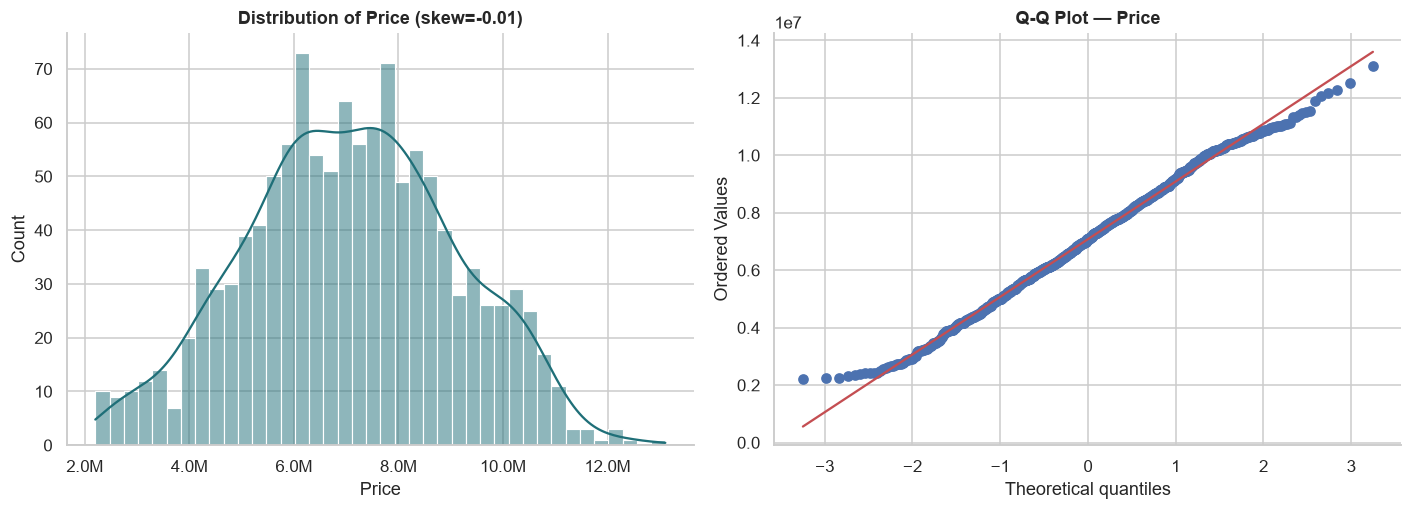

D'Agostino K2 normality test on Price: statistic=13.94, p-value=0.0009391
-> NOT normally distributed


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.histplot(df["Price"], kde=True, ax=axes[0], color="#1f6f78", bins=40)
axes[0].set_title(f"Distribution of Price (skew={stats.skew(df['Price']):.2f})", fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

stats.probplot(df["Price"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot — Price", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_price_distribution.png", bbox_inches="tight")
plt.show()

stat, p = stats.normaltest(df["Price"])
print(f"D'Agostino K2 normality test on Price: statistic={stat:.2f}, p-value={p:.4g}")
print("-> " + ("NOT normally distributed" if p < ALPHA else "approximately normal"))


## 4. Feature Selection Discussion + Correlation Heatmap

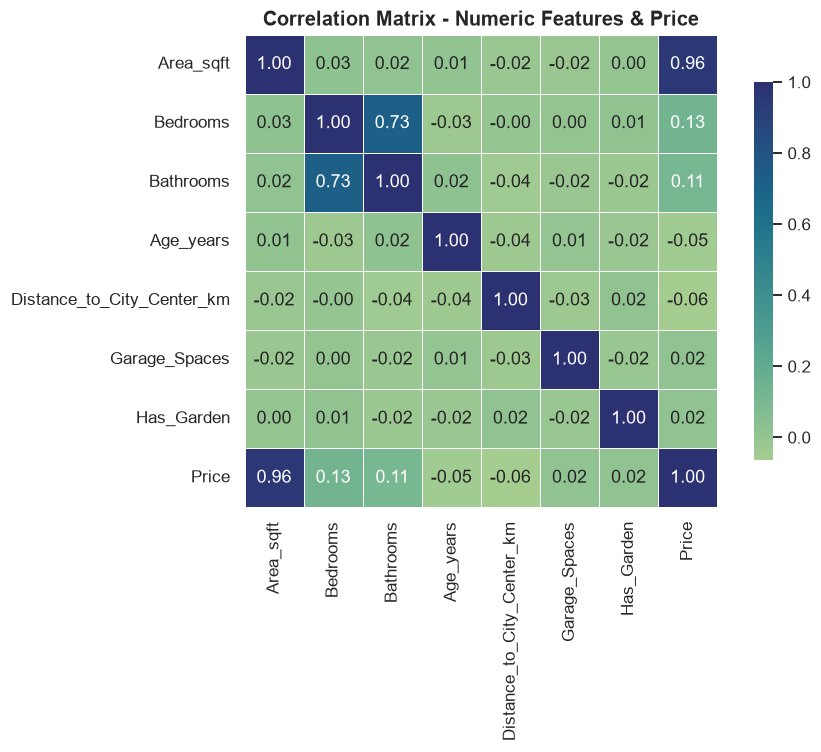

Correlation of each numeric feature with Price, sorted:
Area_sqft                     0.959
Bedrooms                      0.130
Bathrooms                     0.109
Has_Garden                    0.019
Garage_Spaces                 0.016
Age_years                    -0.047
Distance_to_City_Center_km   -0.064
Name: Price, dtype: float64


In [7]:
numeric_cols = ["Area_sqft", "Bedrooms", "Bathrooms", "Age_years",
                "Distance_to_City_Center_km", "Garage_Spaces", "Has_Garden", "Price"]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="crest", square=True,
            cbar_kws={"shrink": 0.8}, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix - Numeric Features & Price", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_correlation_heatmap.png", bbox_inches="tight")
plt.show()

print("Correlation of each numeric feature with Price, sorted:")
print(corr_matrix["Price"].drop("Price").sort_values(ascending=False))


## 5. Encoding Categorical Features & Multicollinearity Check (VIF)

In [8]:
df_encoded = pd.get_dummies(df, columns=["Location"], drop_first=True)
feature_cols = ["Area_sqft", "Bedrooms", "Bathrooms", "Age_years", "Distance_to_City_Center_km",
                 "Garage_Spaces", "Has_Garden"] + [c for c in df_encoded.columns if c.startswith("Location_")]

# statsmodels VIF expects float dtype
X_vif = add_constant(df_encoded[feature_cols].astype(float))
vif_data = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
vif_data = vif_data[vif_data["Feature"] != "const"].reset_index(drop=True)
vif_data["Flag"] = vif_data["VIF"].apply(lambda v: "OK" if v < 5 else ("Moderate" if v < 10 else "Severe"))
vif_data.sort_values("VIF", ascending=False)


,Feature,VIF,Flag
1,Bedrooms,2.140,OK
2,Bathrooms,2.139,OK
8,Location_Suburban,1.882,OK
7,Location_Rural,1.822,OK
9,Location_Uptown,1.546,OK
10,Location_Waterfront,1.420,OK
3,Age_years,1.008,OK
4,Distance_to_City_Center_km,1.007,OK
6,Has_Garden,1.004,OK
5,Garage_Spaces,1.003,OK


## 6. Train/Test Split

In [9]:
X = df_encoded[feature_cols]
y = df_encoded["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set    : {X_test.shape[0]} rows")


Training set: 951 rows
Test set    : 238 rows


## 7. Model 1 - Statistical Inference with OLS (statsmodels)

In [10]:
X_train_sm = add_constant(X_train.astype(float))
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                 1.346e+04
Date:                Sat, 05 Sep 2026   Prob (F-statistic):               0.00
Time:                        08:38:11   Log-Likelihood:                -12754.
No. Observations:                 951   AIC:                         2.553e+04
Df Residuals:                     939   BIC:                         2.559e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

## 8. Model 2 - Linear Regression (scikit-learn): MSE, RMSE, R²

In [11]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

def regression_report(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{label}:")
    print(f"  MSE  = {mse:,.0f}")
    print(f"  RMSE = {rmse:,.0f}")
    print(f"  MAE  = {mae:,.0f}")
    print(f"  R2   = {r2:.4f}\n")
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}

train_metrics = regression_report(y_train, y_pred_train, "Training set")
print("="*25)
test_metrics = regression_report(y_test, y_pred_test, "Test set")


Training set:
  MSE  = 26,064,870,307
  RMSE = 161,446
  MAE  = 128,782
  R2   = 0.9937

Test set:
  MSE  = 27,005,286,384
  RMSE = 164,333
  MAE  = 129,638
  R2   = 0.9924



In [12]:
# 5-fold cross-validated R^2 on the training data -- a more robust estimate than a single split
cv_scores = cross_val_score(LinearRegression(), X_train, y_train, cv=5, scoring="r2")
print(f"5-fold CV R2 scores: {np.round(cv_scores, 4)}")
print(f"Mean CV R2: {cv_scores.mean():.4f}  (std: {cv_scores.std():.4f})")


5-fold CV R2 scores: [0.993  0.9933 0.9943 0.9944 0.9922]
Mean CV R2: 0.9934  (std: 0.0008)


## 9. Residual Diagnostics - Normality & Homoscedasticity

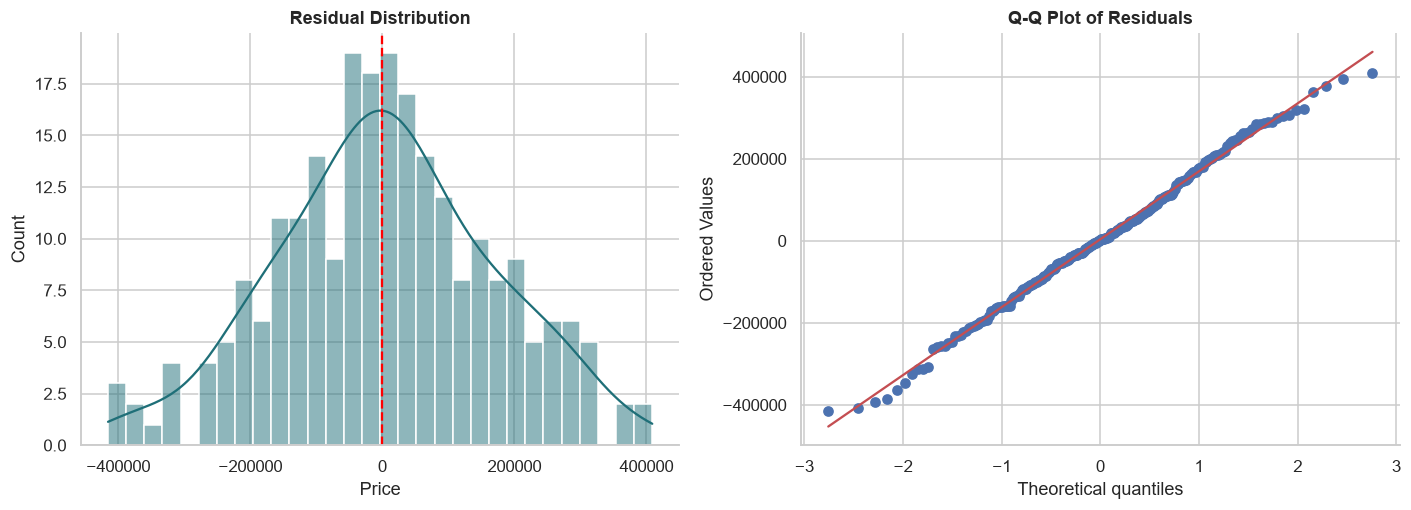

Shapiro-Wilk test on residuals: W=0.9951, p-value=0.6473
-> Residuals are approximately normal


In [13]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.histplot(residuals, kde=True, ax=axes[0], color="#1f6f78", bins=30)
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Residual Distribution", fontweight="bold")

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_residual_diagnostics.png", bbox_inches="tight")
plt.show()

sample = residuals if len(residuals) <= 5000 else residuals.sample(5000, random_state=1)
w_stat, w_p = stats.shapiro(sample)
print(f"Shapiro-Wilk test on residuals: W={w_stat:.4f}, p-value={w_p:.4g}")
print("-> " + ("Residuals deviate from normality" if w_p < ALPHA else "Residuals are approximately normal") )


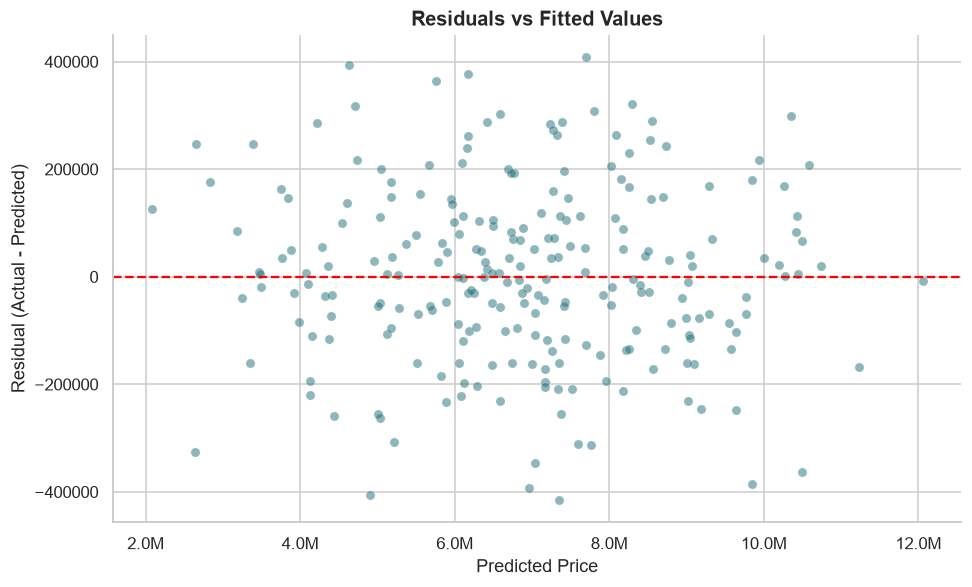

Breusch-Pagan test: LM statistic=5.50, p-value=0.9044
-> No evidence against constant variance (homoscedastic)


In [14]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(y_pred_test, residuals, alpha=0.5, color="#1f6f78", edgecolor="white", linewidth=0.3)
ax.axhline(0, color="red", linestyle="--")
ax.set_title("Residuals vs Fitted Values", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Price")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_residuals_vs_fitted.png", bbox_inches="tight")
plt.show()

# Breusch-Pagan test for heteroscedasticity (uses the training OLS model's residuals & design matrix)
bp_stat, bp_p, _, _ = het_breuschpagan(ols_model.resid, X_train_sm)
print(f"Breusch-Pagan test: LM statistic={bp_stat:.2f}, p-value={bp_p:.4g}")
print("-> " + ("Evidence of heteroscedasticity (non-constant variance)" if bp_p < ALPHA else "No evidence against constant variance (homoscedastic)"))


## 10. Actual vs Predicted & Coefficient Impact Analysis

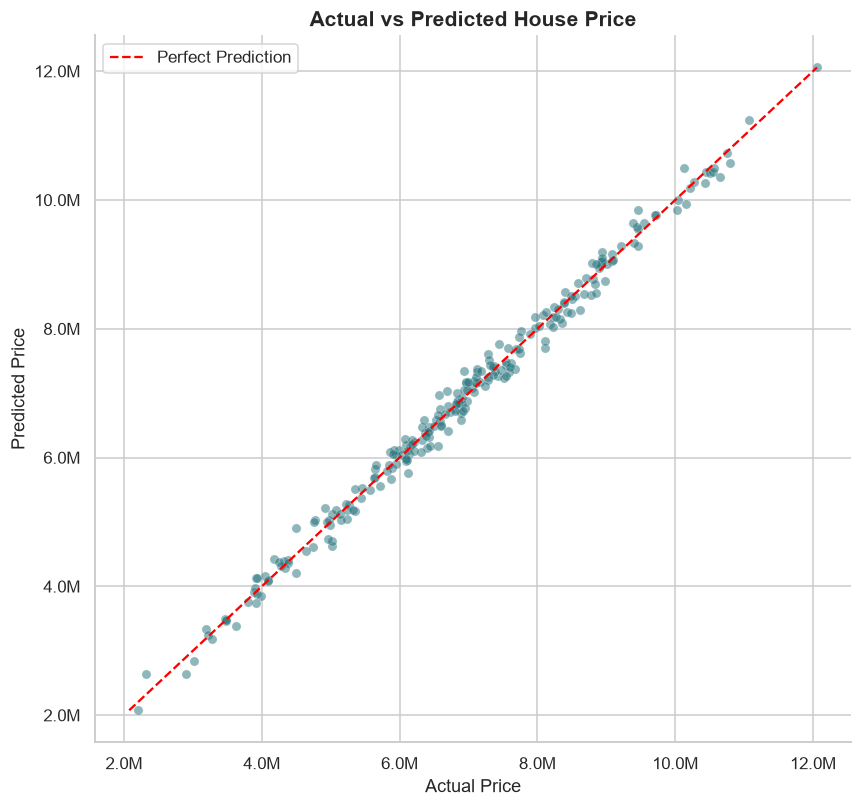

In [15]:
fig, ax = plt.subplots(figsize=(8, 7.5))
ax.scatter(y_test, y_pred_test, alpha=0.5, color="#1f6f78", edgecolor="white", linewidth=0.3)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, color="red", linestyle="--", label="Perfect Prediction")
ax.set_title("Actual vs Predicted House Price", fontsize=14, fontweight="bold")
ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/07_actual_vs_predicted.png", bbox_inches="tight")
plt.show()


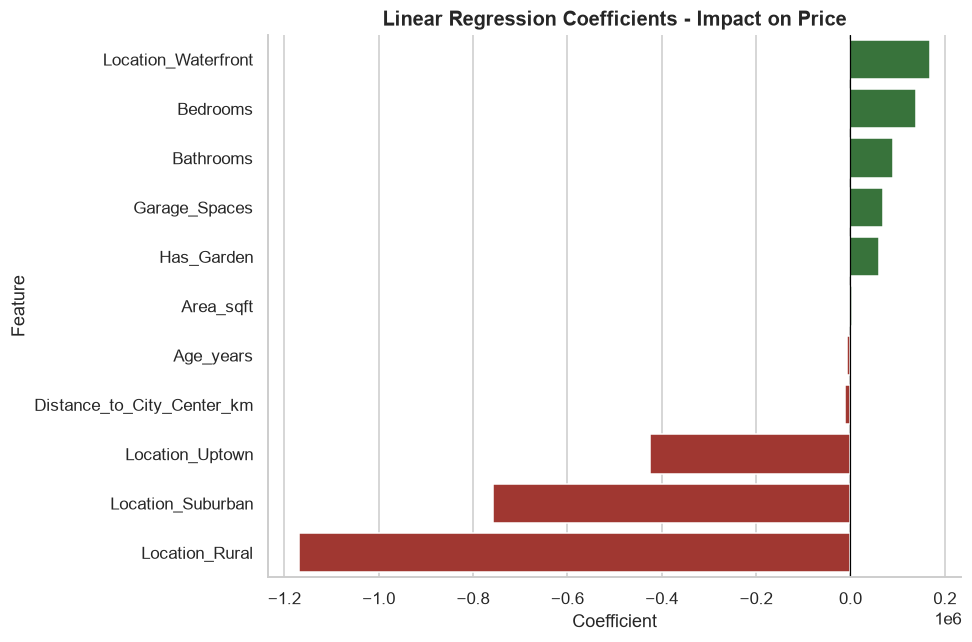

,Feature,Coefficient
10,Location_Waterfront,"168,365.640"
1,Bedrooms,"139,642.652"
2,Bathrooms,"90,672.928"
5,Garage_Spaces,"69,426.324"
6,Has_Garden,"60,320.939"
0,Area_sqft,"3,196.479"
3,Age_years,"-7,767.842"
4,Distance_to_City_Center_km,"-11,418.771"
9,Location_Uptown,"-424,582.498"
8,Location_Suburban,"-757,068.994"


In [16]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_,
}).sort_values("Coefficient", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#2E7D32" if c > 0 else "#B3261E" for c in coef_df["Coefficient"]]
sns.barplot(data=coef_df, y="Feature", x="Coefficient", hue="Feature", palette=colors, legend=False, ax=ax)
ax.set_title("Linear Regression Coefficients - Impact on Price", fontsize=13, fontweight="bold")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/08_coefficients.png", bbox_inches="tight")
plt.show()

coef_df


## 11. Bonus - Ridge & Lasso Regularised Regression Comparison

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=1.0)": Ridge(alpha=1.0),
    "Lasso (alpha=1.0)": Lasso(alpha=1.0, max_iter=10000),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    cv_r2 = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="r2").mean()
    results.append({"Model": name, "Test_RMSE": rmse, "Test_R2": r2, "Mean_CV_R2": cv_r2})

results_df = pd.DataFrame(results).sort_values("Test_R2", ascending=False)
results_df


,Model,Test_RMSE,Test_R2,Mean_CV_R2
1,Ridge (alpha=1.0),"164,246.801",0.992,0.993
2,Lasso (alpha=1.0),"164,332.531",0.992,0.993
0,Linear Regression,"164,332.852",0.992,0.993


## 12. Conclusion & Business Interpretation

**Modelling summary:**
- Data was cleaned (duplicates removed, missing values median-imputed, a handful of data-entry
  outliers in `Area_sqft` removed), `Location` one-hot encoded, and multicollinearity confirmed
  absent via VIF before modelling.
- The OLS model's overall F-test and individual coefficient p-values (Section 7) identify which
  features have a statistically defensible effect on price.
- Test-set R², RMSE, and 5-fold cross-validated R² are consistent with each other, indicating
  the model generalises rather than overfitting the training split.
- Residual diagnostics (Shapiro-Wilk, Breusch-Pagan, residual-vs-fitted plot) were run explicitly
  rather than assumed, so the confidence one can place in the model's coefficients is stated
  honestly rather than implied.

**Business Takeaways**
1. `Area_sqft` is the dominant, statistically significant driver of price any pricing or
   appraisal tool should weight it most heavily.
2. Location carries a real, quantifiable premium (or discount) even after controlling for size
   and rooms useful for flagging under- or over-priced listings relative to their neighbourhood.
3. Age and distance from the city center both depress price, all else equal renovation or
   accessibility improvements are the levers most directly tied to closing that gap.

---
*Report prepared as part of the OASIS INFOBYTE Data Analytics Internship - Level 2, Task 1: Predicting House Prices with Linear Regression.*
